## Felix

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 1. Cargar el dataset
df = pd.read_csv('data\Teen_Mental_Health_Dataset.csv')



<>:12: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
<>:12: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
C:\Users\felix\AppData\Local\Temp\ipykernel_36832\3291419437.py:12: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
  df = pd.read_csv('data\Teen_Mental_Health_Dataset.csv')


In [2]:

# Separamos la variable objetivo si existe
X = df.drop(columns=['depression_label'], errors='ignore')

# Variables para el modelo
categorical_cols = ['gender', 'platform_usage', 'social_interaction_level']
numerical_cols = [col for col in X.columns if col not in categorical_cols]



In [3]:

# MÉTODO 1: Detección Multivariante con Machine Learning (Isolation Forest)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)

# Estimamos un 5% de outliers
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['iforest_outlier'] = iso_forest.fit_predict(X_processed)
# Convertimos a Booleano (True para outlier, False para normal)
df['iforest_outlier'] = df['iforest_outlier'] == -1



In [4]:

# MÉTODO 2: Detección Univariante Estadística (IQR - Rango Intercuartílico)
# Marcamos como outlier si está fuera de [Q1 - 1.5*IQR, Q3 + 1.5*IQR] en CUALQUIER columna numérica
iqr_outliers = pd.Series(False, index=df.index)

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Condición de outlier para esta columna
    col_outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
    iqr_outliers = iqr_outliers | col_outliers

df['iqr_outlier'] = iqr_outliers



In [5]:
# 3. Reporte de Resultados en Consola
print(f"\n --- REPORTE DE OUTLIERS ---")
print(f"Outliers por Isolation Forest (Multivariante): {df['iforest_outlier'].sum()}")
print(f"Outliers por IQR (Univariante por columna): {df['iqr_outlier'].sum()}")



 --- REPORTE DE OUTLIERS ---
Outliers por Isolation Forest (Multivariante): 60
Outliers por IQR (Univariante por columna): 0


C:\Users\felix\AppData\Local\Temp\ipykernel_36832\1409402645.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='platform_usage', y='daily_social_media_hours', data=df, palette='Blues')


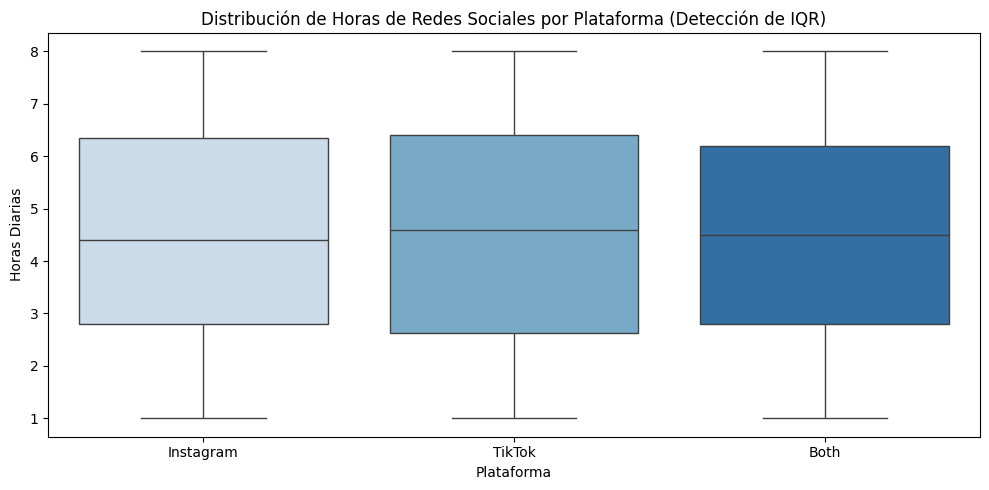

In [8]:
# 4. Visualización de Datos

# Gráfico 1: Seaborn (Boxplot estático para ver la distribución de horas de redes sociales)
plt.figure(figsize=(10, 5))
sns.boxplot(x='platform_usage', y='daily_social_media_hours', data=df, palette='Blues')
plt.title('Distribución de Horas de Redes Sociales por Plataforma (Detección de IQR)')
plt.xlabel('Plataforma')
plt.ylabel('Horas Diarias')
plt.tight_layout()
plt.show()

# Gráfico 2: Plotly (Dispersión Interactiva en 3D usando NumPy para el tamaño)
# Analizamos Horas de Uso vs Estrés vs Rendimiento Académico
fig = px.scatter_3d(
    df, 
    x='daily_social_media_hours', 
    y='stress_level', 
    z='academic_performance',
    color='iforest_outlier', # Colorea según si es outlier por Isolation Forest
    color_discrete_map={False: "#12649e", True: "#f80b0b"}, # Azul formal vs Rojo outlier
    labels={'iforest_outlier': '¿Es Outlier?'},
    title="Análisis de Outliers Multivariante (Isolation Forest)",
    hover_data=['age', 'gender', 'addiction_level'] # Datos al pasar el ratón
)

fig.update_layout(scene=dict(
    xaxis_title='Horas Redes Sociales',
    yaxis_title='Nivel de Estrés',
    zaxis_title='Rendimiento Académico'
))

# 🌟 ALTERNATIVA A NBFORMAT: Forzar renderizado directo en el navegador web
import plotly.io as pio
pio.renderers.default = "browser"

fig.show()

# 5. Guardar resultados
df.to_csv('data\\outliers\\data_con_outliers.csv', index=False)
